<a href="https://colab.research.google.com/github/joelstub/joelstub/blob/main/Knight_Capital_Expanded_Context_Teaching_Notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knight Capital Trading Glitch — Full Teaching Notebook (Expanded Context)
This notebook now includes expanded historical context, detailed narrative explanation, and structured prompts for learning.

## Part 6 — Independent Sensitivity Analysis and Stress Testing
This section extends the original notebook by testing how sensitive the conclusions are to different assumptions about market impact, tail risk, and operational loss severity.

Representative Loss Reconstruction Scenarios:


,Buy Impact,Sell Impact,Total Loss
0,0.015,0.020,245000000.0
1,0.015,0.025,280000000.0
2,0.015,0.030,315000000.0
3,0.015,0.035,350000000.0
4,0.015,0.040,385000000.0



Minimum Total Loss: $245,000,000.00
Maximum Total Loss: $630,000,000.00


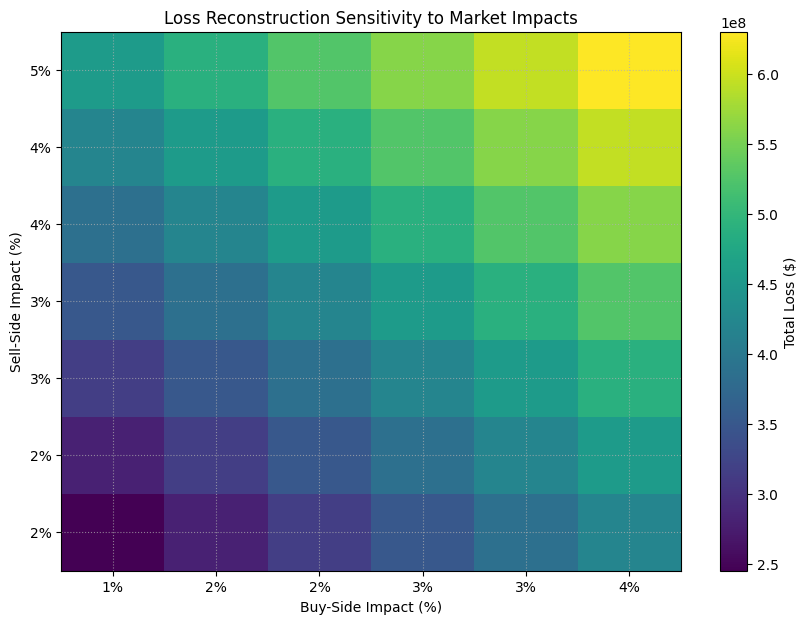

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baseline purchase amount
purchase = 7_000_000_000

# Define ranges for buy-side and sell-side impacts
buy_side_impacts = np.arange(0.015, 0.041, 0.005) # 1.5% to 4.0% in 0.5% steps
sell_side_impacts = np.arange(0.020, 0.051, 0.005) # 2.0% to 5.0% in 0.5% steps

# Generate all combinations of impacts
impact_combinations = []
for buy_impact in buy_side_impacts:
    for sell_impact in sell_side_impacts:
        loss = purchase * (buy_impact + sell_impact)
        impact_combinations.append({
            'Buy Impact': buy_impact,
            'Sell Impact': sell_impact,
            'Total Loss': loss
        })

# Store results in a pandas DataFrame
loss_df = pd.DataFrame(impact_combinations)

# Print representative rows
print("Representative Loss Reconstruction Scenarios:")
display(loss_df.head())

# Print minimum and maximum loss
min_loss = loss_df['Total Loss'].min()
max_loss = loss_df['Total Loss'].max()
print(f"\nMinimum Total Loss: ${min_loss:,.2f}")
print(f"Maximum Total Loss: ${max_loss:,.2f}")

# Visualization: Heatmap of losses
buy_impact_grid, sell_impact_grid = np.meshgrid(buy_side_impacts, sell_side_impacts)
losses_grid = purchase * (buy_impact_grid + sell_impact_grid)

plt.figure(figsize=(10, 7))
plt.pcolormesh(buy_impact_grid, sell_impact_grid, losses_grid, shading='nearest', cmap='viridis')
plt.colorbar(label='Total Loss ($)')
plt.xlabel('Buy-Side Impact (%)')
plt.ylabel('Sell-Side Impact (%)')
plt.title('Loss Reconstruction Sensitivity to Market Impacts')
plt.xticks(buy_side_impacts, [f'{int(i*100)}%' for i in buy_side_impacts])
plt.yticks(sell_side_impacts, [f'{int(i*100)}%' for i in sell_side_impacts])
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

This analysis shows that small changes in market impact percentages can lead to substantial differences in estimated losses. The heatmap clearly visualizes how loss scales directly with both buy and sell-side impacts.

Tail-Risk Sensitivity Analysis:


,Sigma,99th Percentile Loss,99.9th Percentile Loss
0,1.4,1.754668e+09,5.040106e+09
1,1.6,2.765600e+09,9.222132e+09
2,1.8,4.353861e+09,1.650567e+10
3,2.0,6.897317e+09,3.081100e+10


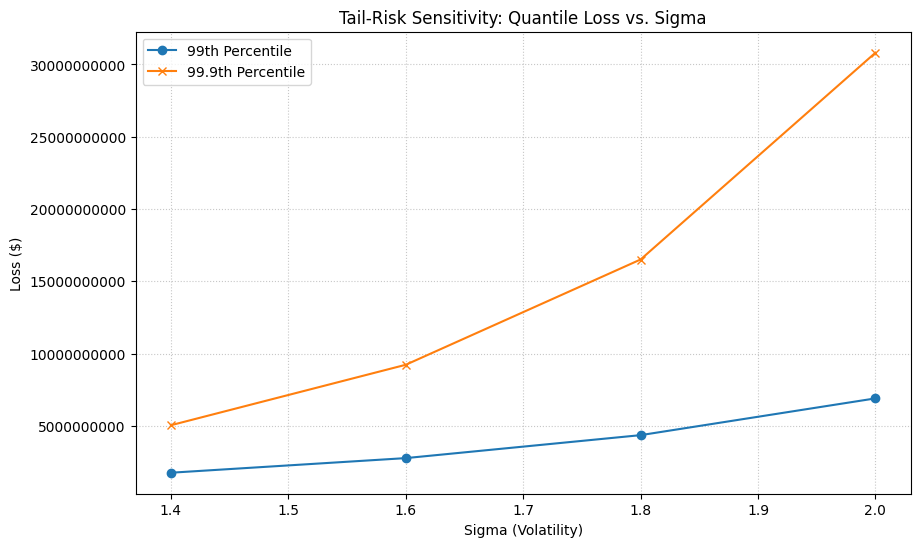

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters for log-normal distribution
mu = 18
num_simulations = 100_000

# Sigma values to compare
sigma_values = [1.4, 1.6, 1.8, 2.0]

# Store results
tail_risk_results = []

for sigma in sigma_values:
    # Simulate losses
    samples = np.random.lognormal(mu, sigma, num_simulations)

    # Compute quantiles
    q99 = np.percentile(samples, 99)
    q99_9 = np.percentile(samples, 99.9)

    tail_risk_results.append({
        'Sigma': sigma,
        '99th Percentile Loss': q99,
        '99.9th Percentile Loss': q99_9
    })

# Store results in a pandas DataFrame
tail_risk_df = pd.DataFrame(tail_risk_results)

# Print the table clearly
print("Tail-Risk Sensitivity Analysis:")
display(tail_risk_df.round(2))

# Visualization: Quantiles vs. Sigma
plt.figure(figsize=(10, 6))
plt.plot(tail_risk_df['Sigma'], tail_risk_df['99th Percentile Loss'], marker='o', label='99th Percentile')
plt.plot(tail_risk_df['Sigma'], tail_risk_df['99.9th Percentile Loss'], marker='x', label='99.9th Percentile')
plt.xlabel('Sigma (Volatility)')
plt.ylabel('Loss ($)')
plt.title('Tail-Risk Sensitivity: Quantile Loss vs. Sigma')
plt.ticklabel_format(style='plain', axis='y') # Remove scientific notation from y-axis
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

This analysis demonstrates that increasing the sigma (volatility) parameter significantly elevates the potential for extreme losses. Even small increases in sigma lead to a disproportional rise in the 99th and 99.9th percentile losses.

SMA Capital Stress Test Results:


,Outlier Loss Scenario,Average Annual Loss,BIC,LC,ILM,SMA Capital
0,440000000,71000000.0,345000000.0,1.065000e+09,1.72,5.929332e+08
1,600000000,87000000.0,345000000.0,1.305000e+09,1.86,6.429227e+08
2,1000000000,127000000.0,345000000.0,1.905000e+09,2.15,7.431776e+08


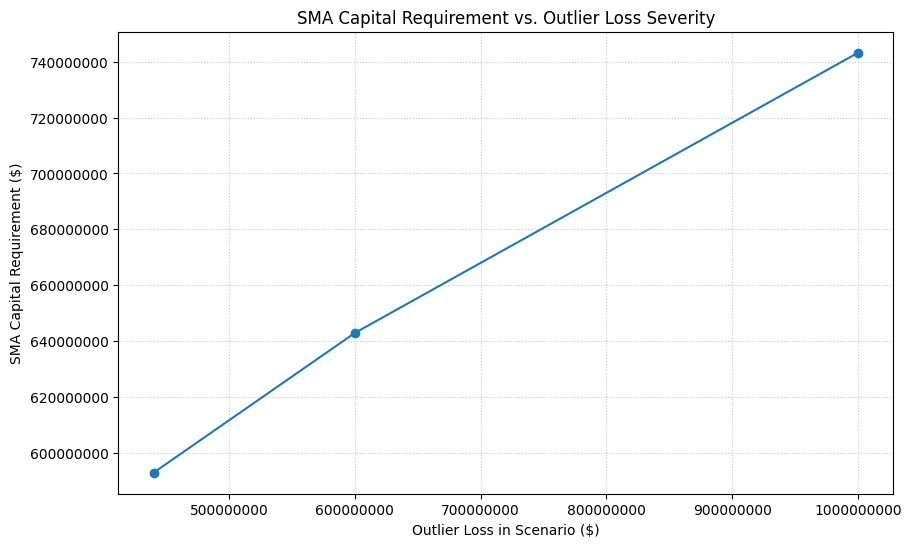

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baseline parameters
BI = 2_500_000_000 # Business Indicator
base_losses = [30_000_000] * 9 # Nine annual losses

# Outlier loss values to stress test
outlier_losses_scenarios = [
    440_000_000, # Original Knight Capital loss
    600_000_000,
    1_000_000_000
]

# Store results
sma_capital_results = []

for outlier_loss in outlier_losses_scenarios:
    # Construct the full list of losses for the scenario
    current_losses = base_losses + [outlier_loss]

    # Calculate average annual loss
    avg = np.mean(current_losses)

    # Calculate BIC (Business Indicator Component)
    BIC = 0.12e9 + 0.15 * (BI - 1e9)

    # Calculate LC (Loss Component)
    LC = 15 * avg

    # Calculate ILM (Internal Loss Multiplier)
    # Ensure 0.8 * BIC is not zero to avoid division by zero
    if (0.8 * BIC) == 0:
        ILM = np.nan # Or handle as appropriate
    else:
        ILM = np.log(np.e - 1 + LC / (0.8 * BIC))

    # Calculate final capital requirement
    capital = BIC * ILM

    sma_capital_results.append({
        'Outlier Loss Scenario': outlier_loss,
        'Average Annual Loss': avg,
        'BIC': BIC,
        'LC': LC,
        'ILM': ILM,
        'SMA Capital': capital
    })

# Store results in a pandas DataFrame
sma_capital_df = pd.DataFrame(sma_capital_results)

# Print the table clearly
print("SMA Capital Stress Test Results:")
display(sma_capital_df.round(2))

# Visualization: SMA Capital vs. Outlier Loss
plt.figure(figsize=(10, 6))
plt.plot(sma_capital_df['Outlier Loss Scenario'], sma_capital_df['SMA Capital'], marker='o', linestyle='-')
plt.xlabel('Outlier Loss in Scenario ($)')
plt.ylabel('SMA Capital Requirement ($)')
plt.title('SMA Capital Requirement vs. Outlier Loss Severity')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

This stress test reveals a non-linear relationship where increasing the severity of a single outlier loss significantly impacts the calculated SMA capital requirement. This highlights how extreme events can disproportionately drive regulatory capital needs.

## Background: What Happened at Knight Capital?
On August 1, 2012, Knight Capital — then one of the largest U.S. equity market makers — deployed new code intended to interact with the NYSE's Retail Liquidity Program. However, a dormant testing module (called *Power Peg*) was accidentally reactivated. When markets opened, this module sent millions of unintended buy and sell orders across 150+ stocks, causing Knight to accumulate nearly 7 billion in unintended positions within 45 minutes. According to reports, this resulted in losses of approximately 440 million as Knight unwound the positions.


## Why This is a Model Risk Event
Even though the failure was software-driven, it represents a textbook case of *model risk*: deploying untested logic, lack of governance, inadequate change management, and absence of independent verification.

## Task 1 — Interpret the Incident
- Summarize the event in your own words.
- Identify five SR 11-7 failures.

Summarize the event in your own words: For this part, you'll need to read the 'Background: What Happened at Knight Capital?' and 'Why This is a Model Risk Event' sections. Your goal is to distill the core information into your own narrative, explaining what occurred, the key players, the cause of the glitch (the Power Peg module), and the immediate financial outcome.

Identify five SR 11-7 failures: SR 11-7 refers to the Supervisory Guidance on Model Risk Management, a crucial regulatory framework in finance. The notebook already provides significant clues in the 'Why This is a Model Risk Event' section, explicitly mentioning aspects like 'untested logic,' 'lack of governance,' 'inadequate change management,' and 'absence of independent verification.' You should elaborate on these or identify other related failures from the incident that would fall under the scope of SR 11-7 principles.

Review Incident Background: Carefully read the 'Background: What Happened at Knight Capital?' and 'Why This is a Model Risk Event' sections to understand the details of the Knight Capital incident.
Summarize Event: Synthesize the information gathered into a concise summary of the Knight Capital trading glitch in your own words, covering the key aspects of what, when, how, and the immediate consequences.
Identify SR 11-7 Failures: Based on the detailed explanation in the notebook, particularly the 'Why This is a Model Risk Event' section, identify five specific failures that align with the principles and guidelines outlined in SR 11-7 (Supervisory Guidance on Model Risk Management). This may require external knowledge of SR 11-7 or inferring common model risk management failures from the provided text.
Final Task: Present the summary of the event and the five identified SR 11-7 failures as a complete response.

## Task 2 — Loss Reconstruction

### Explanation of Loss Reconstruction

This section calculates the estimated financial loss incurred by Knight Capital due to the trading glitch. The calculation is based on the following variables:

-   `purchase`: Represents the estimated total value of the unintended positions accumulated by Knight Capital. In this case, it's set to $7 billion (7,000,000,000).
-   `impact_up`: Represents the upward price impact (percentage increase) on the stocks as Knight Capital bought them, inadvertently driving prices higher. This is set to 2.5% (0.025).
-   `impact_down`: Represents the downward price impact (percentage decrease) on the stocks as Knight Capital unwound its positions, selling them and driving prices lower. This is set to 3.5% (0.035).
-   `loss`: This variable calculates the total financial loss. It is determined by multiplying the `purchase` amount by the sum of `impact_up` and `impact_down`. The sum of `impact_up` and `impact_down` represents the total percentage price movement (both positive and negative) that contributed to the loss during the buying and selling process.

The formula used is `loss = purchase * (impact_up + impact_down)`. This means that the total loss is a direct result of the large volume of trades (`purchase`) and the combined adverse price movements (`impact_up` + `impact_down`) experienced during the incident.

In [ ]:
purchase=7_000_000_000
impact_up=0.025
impact_down=0.035
loss=purchase*(impact_up+impact_down)
print(f"Total Loss: ${loss:,.2f}")

Total Loss: $420,000,000.00


## Task 3 — Tail Risk Plot

### Explanation of the 'Distribution of Potential Losses' Plot

This histogram visualizes the frequency of different potential loss amounts based on a log-normal distribution, often used to model financial risks.

*   **X-axis (Loss ($))**: Represents the magnitude of potential losses in U.S. dollars. It shows a wide range, from smaller, more frequent losses to larger, less frequent ones.
*   **Y-axis (Frequency (log scale))**: Shows how often each loss amount occurs. The use of a **logarithmic scale** allows for better visualization of events that occur with vastly different frequencies. This is particularly useful for 'tail risk' events, which are rare but have a significant impact.

**Key Takeaway**: The plot illustrates a typical **log-normal distribution**, characterized by a long right tail. This indicates that while most potential losses might be relatively small, there is a distinct, albeit low, probability of experiencing extremely large losses (known as 'tail risk'). This is critical for understanding and managing financial risk, as these extreme events can have disproportionate impacts, as seen in the Knight Capital incident.

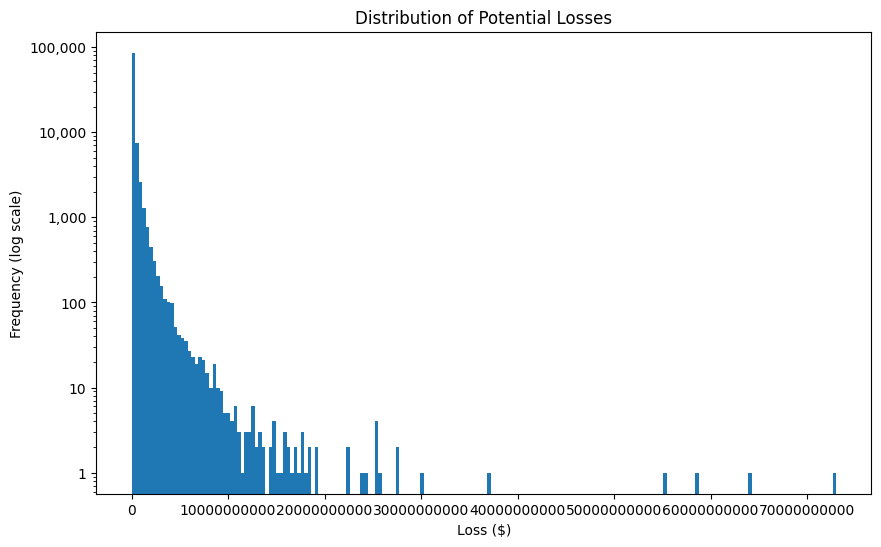

np.float64(8856794539.376673)

In [ ]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Import ticker module

mu, sigma = 18, 1.6
samples=np.random.lognormal(mu,sigma,100000)
plt.figure(figsize=(10, 6)) # Increase plot size
plt.hist(samples,bins=200,log=True)

plt.ticklabel_format(style='plain', axis='x') # Remove scientific notation from x-axis

# Use a custom formatter for the log-scaled y-axis to remove scientific notation
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.xlabel('Loss ($)') # Add x-axis label
plt.ylabel('Frequency (log scale)') # Add y-axis label
plt.title('Distribution of Potential Losses') # Add a title
plt.show()
np.percentile(samples,99.9)

## Task 4 — SMA Calculator

Explain SMA Calculator Context: Provide an overview of what the SMA Calculator represents in the context of financial risk management and its relevance to the Knight Capital incident, even if indirectly.

Explain Variables: Detail each variable used in the SMA Calculator code cell: BI, losses, avg, BIC, LC, ILM, and capital, describing their definitions and values.

Explain Formulas: Break down and explain the formulas used to calculate BIC (Business Indicator Component), LC (Loss Component), ILM (Internal Loss Multiplier), and the final capital requirement, clarifying their financial interpretation.

Summarize Purpose: Conclude by summarizing the overall purpose of Task 4 within the notebook, linking it to the assessment or quantification of operational risk capital requirements.

Final Task: Provide a comprehensive explanation of Task 4, including the context, variables, formulas, and its overall objective.

In [ ]:
import numpy as np
BI=2500000000
losses=[30000000]*9+[440000000]
avg=np.mean(losses)
BIC=0.12e9+0.15*(BI-1e9)
LC=15*avg
ILM=np.log(np.e-1+LC/(0.8*BIC))
capital=BIC*ILM
print(f"BIC: ${BIC:,.2f}")
print(f"LC: ${LC:,.2f}")
print(f"ILM: {ILM:.4f}")
print(f"Capital: ${capital:,.2f}")

BIC: $345,000,000.00
LC: $1,065,000,000.00
ILM: 1.7186
Capital: $592,933,201.03


## Task 5 — Glitch Simulation

The Python code in Task 5 simulates a trading glitch scenario, similar to the Knight Capital incident, by generating initial stock prices, calculating a sudden price 'jump' (increase), and then deriving new, affected prices. It utilizes `numpy` for efficient numerical operations and `matplotlib` for data visualization.

Here's a breakdown of each part:

1.  **Generating Initial Stock Prices (`prices`)**:
    ```python
    prices = np.random.uniform(20, 200, 50)
    ```
    This line uses `numpy.random.uniform(low, high, size)` to create an array named `prices`. It generates 50 (specified by `size=50`) random floating-point numbers, each uniformly distributed between a `low` value of 20 and a `high` value of 200. This array represents the initial, pre-glitch stock prices for 50 different hypothetical stocks.

2.  **Calculating the Price 'Jump' (`jump`)**:
    ```python
    jump = prices * np.random.uniform(0.05, 0.25, 50)
    ```
    To simulate a sudden price increase (a 'jump'), this line calculates `jump` by taking the `prices` array and multiplying each initial price by a random percentage. `np.random.uniform(0.05, 0.25, 50)` generates another array of 50 random values, this time between 0.05 (5%) and 0.25 (25%). When multiplied by `prices`, this effectively creates an array where each element represents a random percentage increase (between 5% and 25%) of its corresponding initial stock price. This simulates the unintended buying pressure and subsequent price distortion seen in market glitches.

3.  **Deriving New Prices (`newp`)**:
    ```python
    newp = prices + jump
    ```
    This line calculates the `newp` array, which represents the stock prices **after** the glitch. It does this by simply adding the calculated `jump` (the price increase) to the original `prices` array. Each element in `newp` is the sum of an initial price and its corresponding jump, showing the inflated price due to the simulated glitch.

4.  **Role of `numpy`**:
    `numpy` (Numerical Python) is fundamental here for its ability to perform fast and efficient array operations. Instead of using Python loops, which would be much slower for large datasets, `numpy` allows vectorized operations (like element-wise multiplication and addition on entire arrays). This makes the code concise, readable, and highly performant for numerical computations, which is crucial in financial modeling and simulations involving large amounts of data.

5.  **Plotting the Changes with `matplotlib`**:
    ```python
    plt.plot(prices); plt.plot(newp); plt.show()
    ```
    `matplotlib.pyplot` (aliased as `plt`) is used for visualizing the data. The first `plt.plot(prices)` command plots the initial stock prices, and the second `plt.plot(newp)` command plots the new, post-glitch prices on the same graph. By plotting both, the user can visually compare the original prices with the prices after the simulated glitch, clearly showing the 'jump'. Finally, `plt.show()` displays the generated plot.

### Explanation of the 'Glitch Simulation' Plot

This plot visually represents a simulated market glitch, akin to what occurred during the Knight Capital incident, by showing the immediate impact on stock prices. It displays two distinct lines:

*   **Blue Line ('prices')**: Represents the original, underlying prices of 50 different stocks before the glitch occurred. These are the baseline prices.
*   **Orange Line ('newp')**: Represents the new, increased prices of the same 50 stocks after the simulated glitch. This line shows the prices after an 'unintended jump' has been applied.

**Visualizing the Glitch's Impact:**
The plot clearly demonstrates the immediate and widespread effect of the simulated glitch. For every stock, the orange line ('newp') is consistently above the blue line ('prices'), illustrating a rapid and unintended upward shift in prices across the board. This 'jump' in prices is a direct visual representation of how erroneous trading algorithms, like the one at Knight Capital, can instantaneously inflate asset values due to massive, unwarranted buy orders.

**Relevance to Knight Capital:**
This visualization directly parallels the market disruption experienced by Knight Capital. The original 'prices' can be thought of as the stable market before August 1, 2012. The 'newp' represents the prices as Knight Capital's Power Peg module sent millions of unintended orders, driving prices significantly higher. The plot effectively illustrates the rapid, unintended price movements and the immediate market distortion that such technical malfunctions can cause, leading to massive financial losses as positions are accumulated at artificially inflated prices.

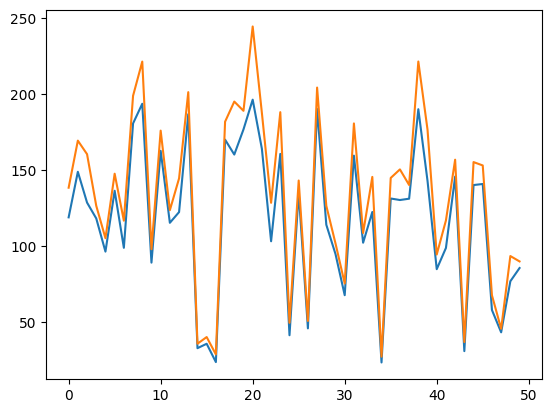

In [ ]:
import numpy as np, matplotlib.pyplot as plt
np.random.seed(0)
prices=np.random.uniform(20,200,50)
jump=prices*np.random.uniform(0.05,0.25,50)
newp=prices+jump
plt.plot(prices); plt.plot(newp); plt.show()